In [3]:
import glob
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [4]:
model_name = 'multipeak-finetune-cFrF-picked-kfolds-aug'

In [48]:
def plot_loss(kfold):
    loss = pd.read_csv(f'handpicked-kfold-results/augmented_dataset_results/5fold-results/200epochs/per-fold-results/{model_name}+MLP+two_lightcurve_kfold{kfold}_w1.0_loss_outputs.csv',
                    skiprows=1, names=['epoch','loss','loss_val'])
    
    best_loss_val = np.log10(loss['loss_val']).min()
    best_loss_val_epoch = loss.loc[loss['loss_val'].idxmin(), 'epoch']

    plt.figure()
    plt.plot(loss['epoch'], np.log10(loss['loss']), label='Training', color='#D48FB3', linewidth=4)
    plt.plot(loss['epoch'], np.log10(loss['loss_val']), label='Validation', color='#7A79CC', linewidth=4)
    plt.axvline(best_loss_val_epoch, label='epoch '+str(int(best_loss_val_epoch)), zorder=0, color='gray', alpha=0.4)
    plt.axhline(best_loss_val, zorder=0, color='gray', alpha=0.4)
    plt.xlabel('Epoch', fontsize=20)
    plt.ylabel('log$_{10}$(loss)', fontsize=20, )
    plt.title(f'KFOLD {kfold}')

    plt.tick_params(left=True, bottom=True, axis='both', labelsize=17)

    plt.legend(frameon=False, fontsize=15)
    plt.tight_layout()

    print(kfold, int(best_loss_val_epoch))

0 124
1 99
2 110
3 89
4 118


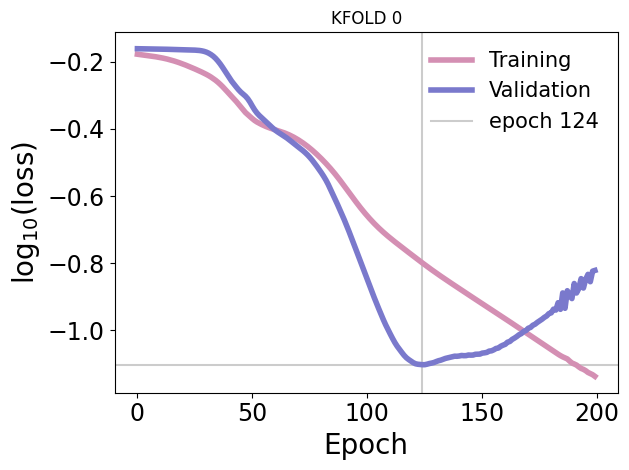

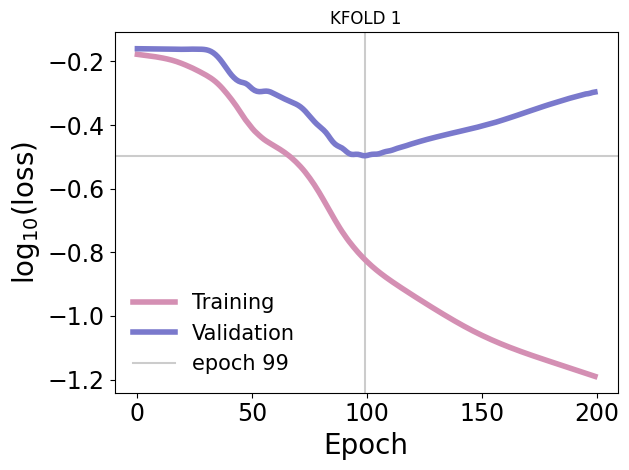

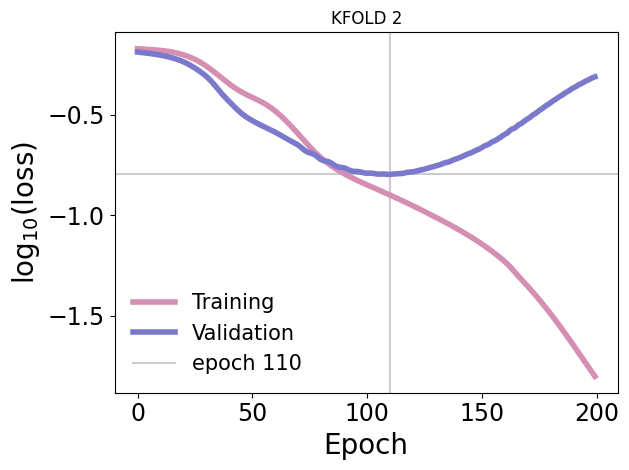

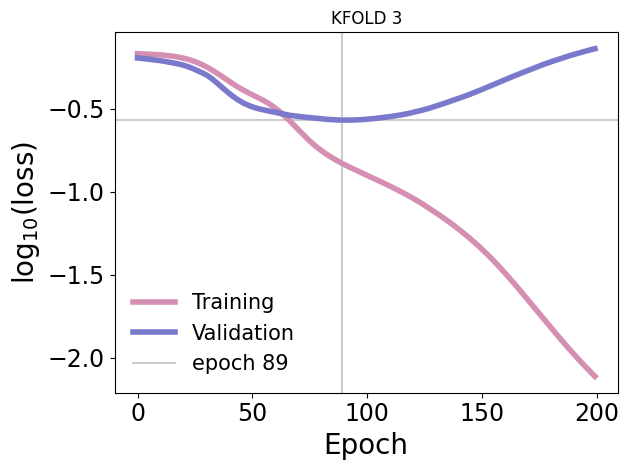

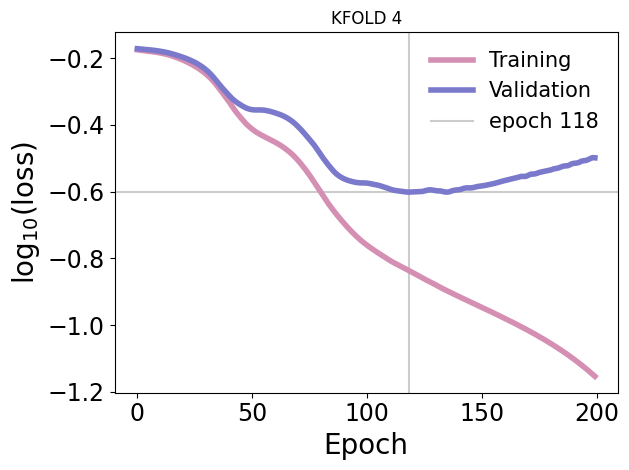

In [ ]:
for i in range(5):
    plot_loss(i)

In [ ]:

for i in range(5):
    best_fnames = glob.glob(f'models/mlp-states/5fold-longrun/{model_name}+MLP+two_lightcurve_kfold{i}_w1.0_epoch*.pt')
    print(f'KFOLD{i}', best_fnames[-1])